# 06 - Neural Network From Scratch
Train a complete 2-layer Neural Network on dummy data using NumPy.

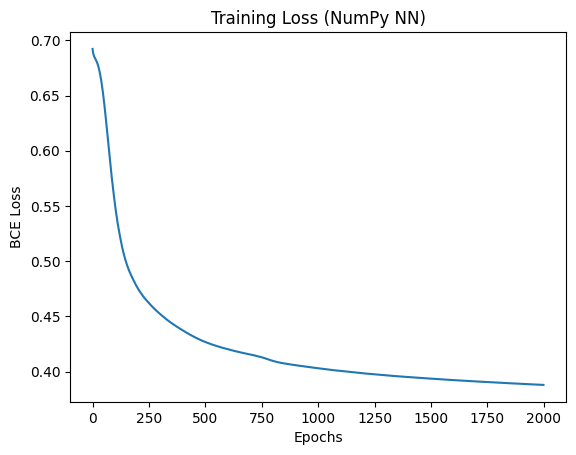

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Generate Data
np.random.seed(42)
X = np.random.randn(2, 400)
Y = np.logical_xor(X[0,:] > 0, X[1,:] > 0).astype(int).reshape(1, 400)

# Architecture
W1 = np.random.randn(4, 2) * 0.1
b1 = np.zeros((4, 1))
W2 = np.random.randn(1, 4) * 0.1
b2 = np.zeros((1, 1))

learning_rate = 0.5
losses = []

for i in range(2000):
    # Forward Prop
    Z1 = np.dot(W1, X) + b1
    A1 = np.maximum(0, Z1) # ReLU
    Z2 = np.dot(W2, A1) + b2
    A2 = 1 / (1 + np.exp(-Z2)) # Sigmoid
    
    # Loss
    cost = -np.mean(Y * np.log(A2 + 1e-8) + (1-Y) * np.log(1-A2 + 1e-8))
    losses.append(cost)
    
    # Backprop
    dZ2 = A2 - Y
    dW2 = 1/400 * np.dot(dZ2, A1.T)
    db2 = 1/400 * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = np.dot(W2.T, dZ2) * (Z1 > 0)
    dW1 = 1/400 * np.dot(dZ1, X.T)
    db1 = 1/400 * np.sum(dZ1, axis=1, keepdims=True)
    
    # Update
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

plt.plot(losses)
plt.title('Training Loss (NumPy NN)')
plt.xlabel('Epochs')
plt.ylabel('BCE Loss')
plt.show()